In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [13]:
data = []
labels = []
file_name = []

target_size = (256, 256)
dataset_path = "/content/drive/MyDrive/PROJECT_PCD/Dataset"

# Sort folder kelas
for sub_folder in sorted(os.listdir(dataset_path)):

    sub_folder_path = os.path.join(dataset_path, sub_folder)

    # Pastikan yang dibaca hanya folder
    if os.path.isdir(sub_folder_path):

        # Sort file gambar
        for filename in sorted(os.listdir(sub_folder_path)):

            img_path = os.path.join(sub_folder_path, filename)

            img = cv.imread(img_path)

            # Lewati jika gambar gagal dibaca
            if img is None:
                print(f"Gagal membaca: {img_path}")
                continue

            img = img.astype(np.uint8)
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, target_size)

            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

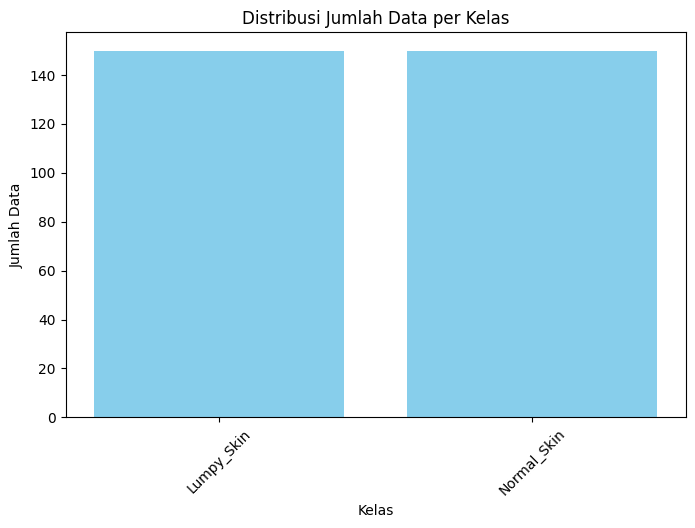

In [14]:
# Menampilkan jumlah data per kelas
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique_labels, counts, color='skyblue')
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Jumlah Data per Kelas")
plt.xticks(rotation=45)
plt.show()

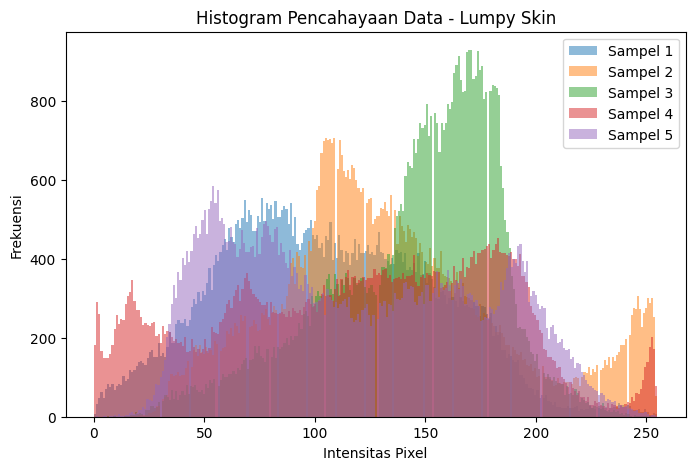

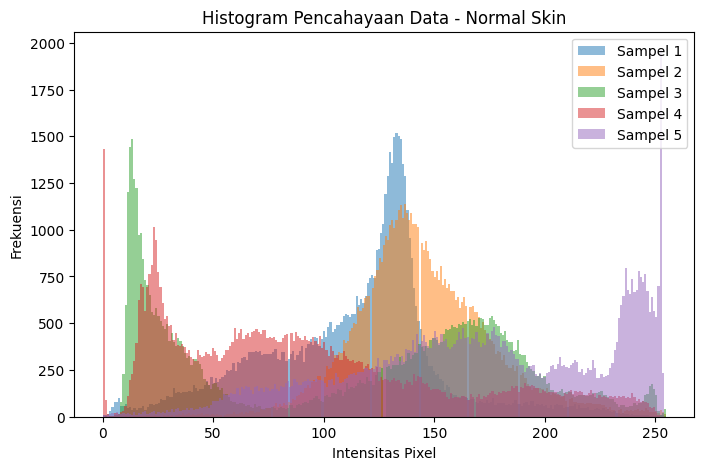

In [15]:
Lumpy_Skin = [data[i] for i in range(len(labels)) if labels[i] == "Lumpy_Skin"]
Normal_skin = [data[i] for i in range(len(labels)) if labels[i] == "Normal_Skin"]

plt.figure(figsize=(8, 5))
for i in range(min(5, len(Lumpy_Skin))):
    img = Lumpy_Skin[i]
    plt.hist(img.ravel(), bins=256, alpha=0.5, label=f'Sampel {i+1}')
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi")
plt.title("Histogram Pencahayaan Data - Lumpy Skin")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for i in range(min(5, len(Normal_skin))):
    img = Normal_skin[i]
    plt.hist(img.ravel(), bins=256, alpha=0.5, label=f'Sampel {i+1}')
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi")
plt.title("Histogram Pencahayaan Data - Normal Skin")
plt.legend()
plt.show()

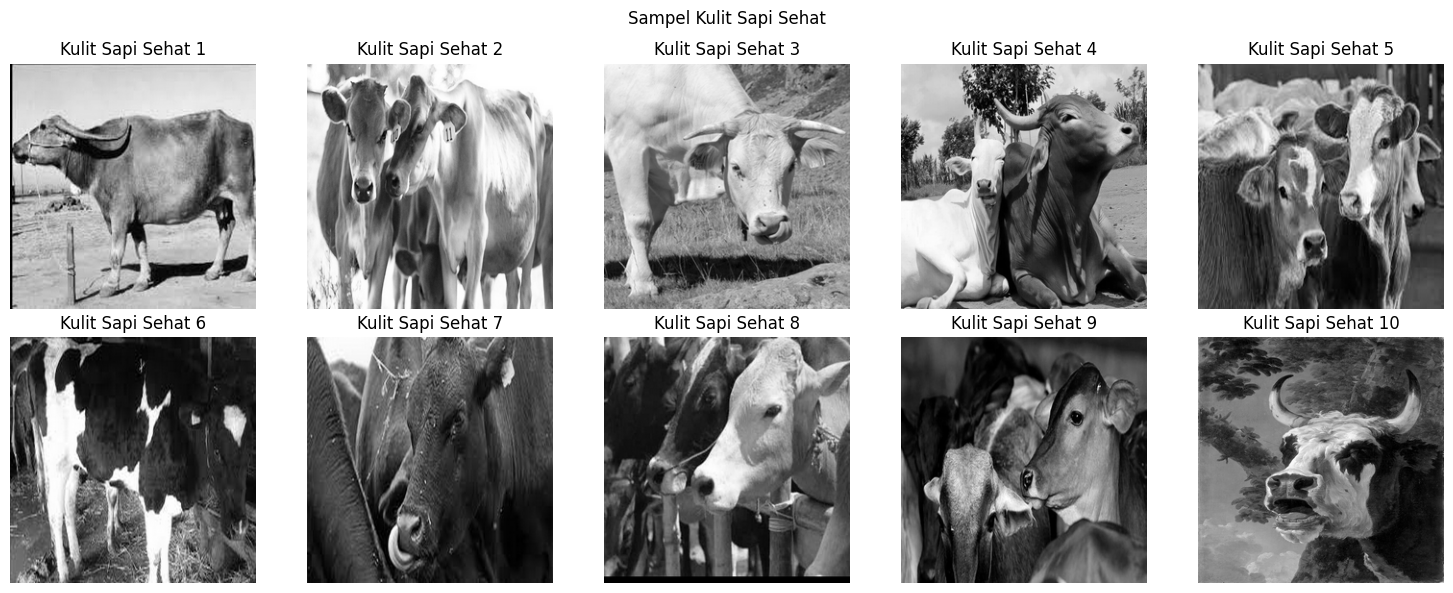

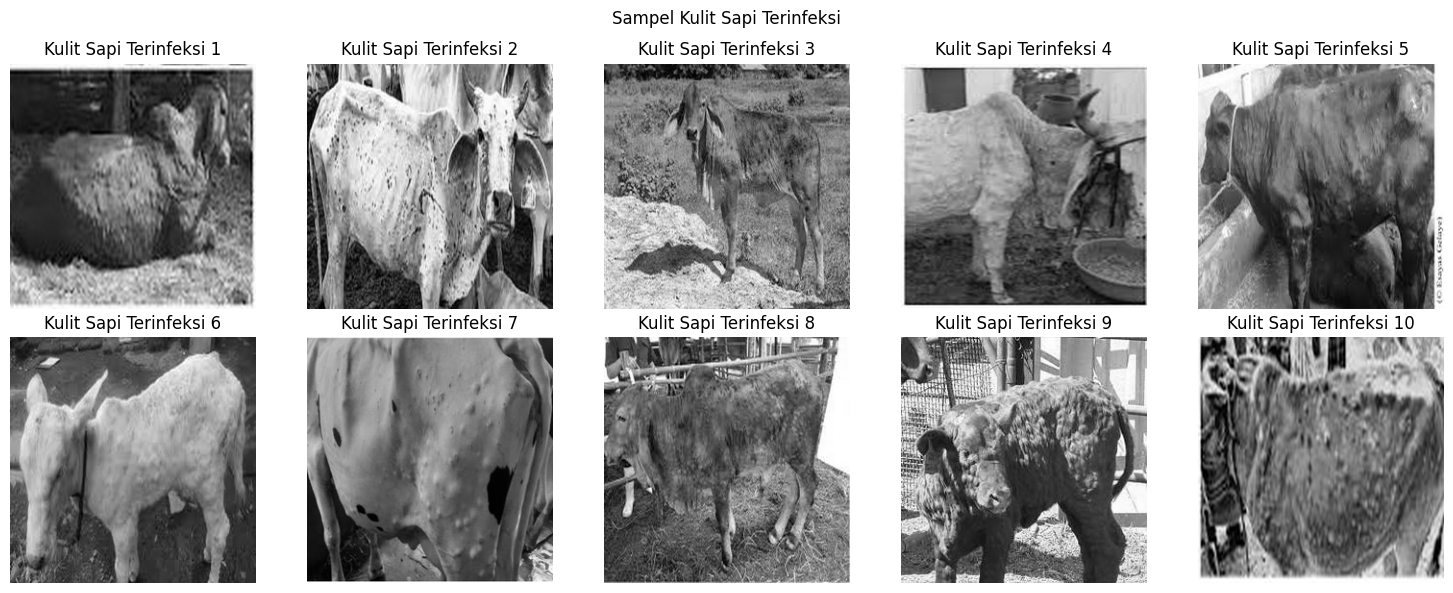

In [ ]:
import random

# Menampilkan sampel kulit sapi sehat
random_normal = random.sample(Normal_skin, min(10, len(Normal_skin)))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(min(10, len(random_normal))):
    axes[i].imshow(random_normal[i], cmap="gray")
    axes[i].set_title(f"Kulit Sapi Sehat {i+1}")
    axes[i].axis("off")
plt.suptitle("Sampel Kulit Sapi Sehat")
plt.tight_layout()
plt.show()

# Menampilkan sampel kulit sapi terinfeksi
random_lumpy = random.sample(Lumpy_Skin, min(10, len(Lumpy_Skin)))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(min(10, len(random_lumpy))):
    axes[i].imshow(random_lumpy[i], cmap="gray")
    axes[i].set_title(f"Kulit Sapi Terinfeksi {i+1}")
    axes[i].axis("off")
plt.suptitle("Sampel Kulit Sapi Terinfeksi")
plt.tight_layout()
plt.show()

In [16]:
augmented = {
    'data': [],
    'labels': [],
    'filenames': []
}

# Proses augmentasi
for i in range(len(data)):
    img = data[i]
    label = labels[i]
    filename = file_name[i]

    # 1. Flip Horizontal
    img_flip_h = cv.flip(img, 1)

    # 2. Flip Vertikal
    img_flip_v = cv.flip(img, 0)

    # 3. Rotasi 90 Derajat
    img_rot_90 = cv.rotate(img, cv.ROTATE_90_CLOCKWISE)

    # 4. Rotasi 180 Derajat
    img_rot_180 = cv.rotate(img, cv.ROTATE_180)

    # Simpan semua hasil ke dalam dictionary 'augmented'
    augmented_images = [
        (img_flip_h, 'flip_h'),
        (img_flip_v, 'flip_v'),
        (img_rot_90, 'rot_90'),
        (img_rot_180, 'rot_180'),
    ]

    for img_aug, suffix in augmented_images:
        augmented['data'].append(img_aug)
        augmented['labels'].append(label)
        augmented['filenames'].append(f"{filename}_{suffix}")

# Tampilkan hasil
print("Jumlah data sebelum augmentasi:", len(data))
print("Jumlah data setelah augmentasi:", len(augmented['data']))

Jumlah data sebelum augmentasi: 300
Jumlah data setelah augmentasi: 1200


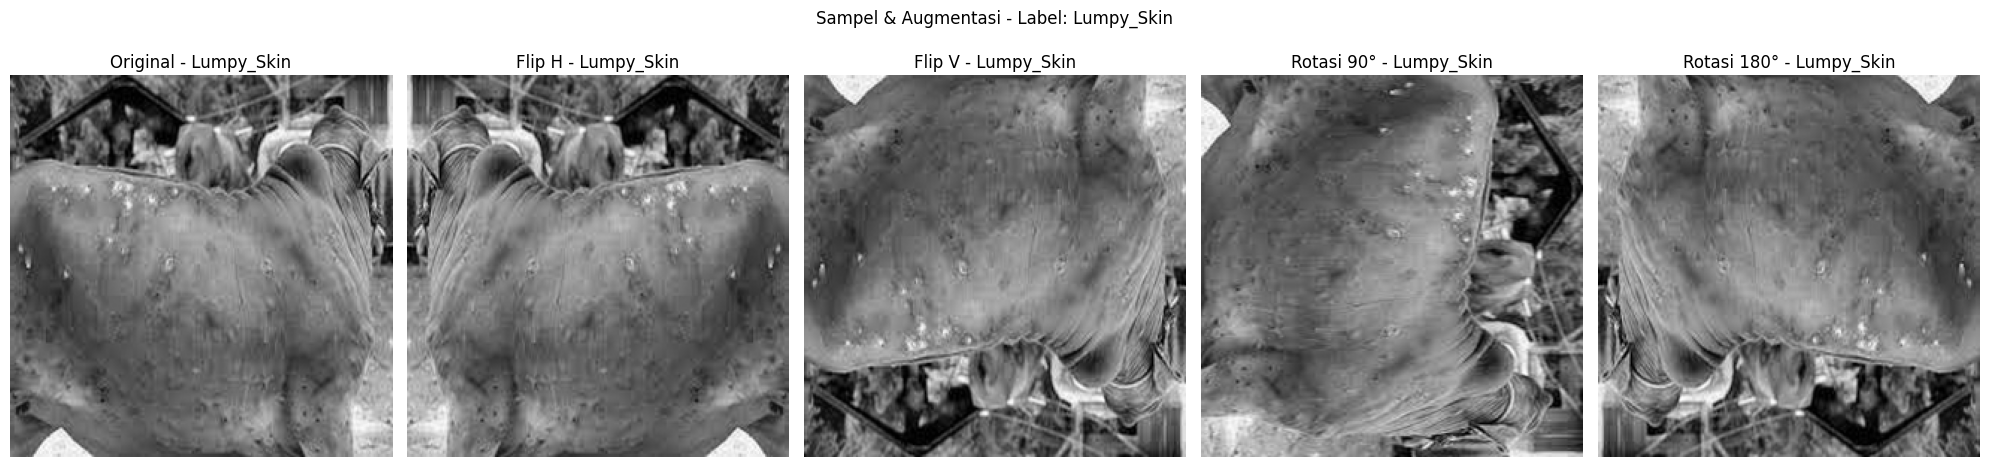

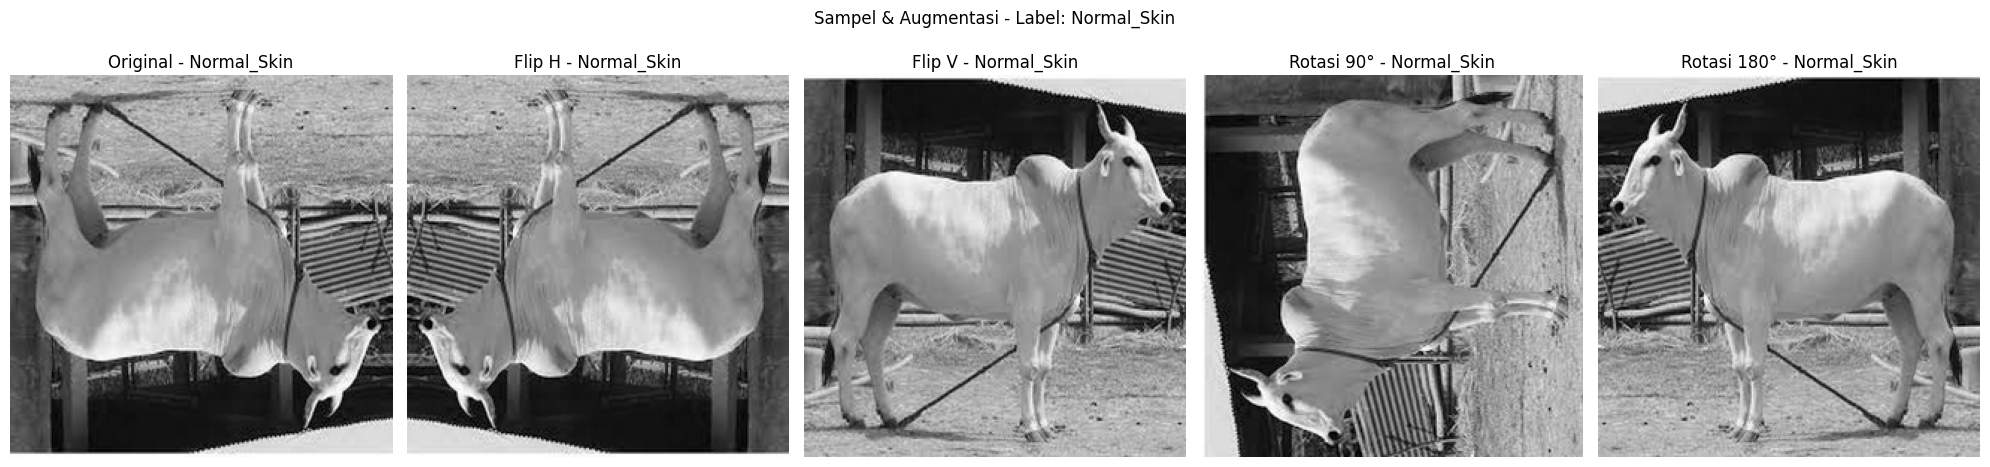

In [17]:
import random

# Ambil label unik dari data yang telah di-augmentasi
unique_labels = np.unique(augmented['labels'])

for label in unique_labels:
    # Ambil semua gambar yang label-nya sama
    samples = [augmented['data'][i] for i in range(len(augmented['labels'])) if augmented['labels'][i] == label]

    if len(samples) > 0:
        sample_img = random.choice(samples)  # Ambil satu contoh gambar

        # Siapkan tampilan
        fig, axes = plt.subplots(1, 5, figsize=(20, 5))
        augment_titles = ["Original", "Flip H", "Flip V", "Rotasi 90°", "Rotasi 180°"]

        # Daftar gambar hasil augmentasi tanpa translasi
        augmentations = [
            sample_img,
            cv.flip(sample_img, 1),
            cv.flip(sample_img, 0),
            cv.rotate(sample_img, cv.ROTATE_90_CLOCKWISE),
            cv.rotate(sample_img, cv.ROTATE_180)
        ]

        # Tampilkan semua hasil dalam satu baris
        for i in range(5):
            axes[i].imshow(augmentations[i], cmap="gray")
            axes[i].set_title(f"{augment_titles[i]} - {label}")
            axes[i].axis("off")

        plt.suptitle(f"Sampel & Augmentasi - Label: {label}")
        plt.tight_layout()
        plt.show()


In [18]:
def normalize(img):
    img = img.astype(np.float32)
    min_val = np.min(img)
    max_val = np.max(img)
    if max_val - min_val == 0:
        return np.zeros_like(img, dtype=np.uint8)
    norm_img = (img - min_val) / (max_val - min_val) * 255
    return norm_img.astype(np.uint8)

def histogram_equalization(img):
    # Histogram Equalization secara manual
    hist, bins = np.histogram(img.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_min = cdf_masked.min()
    cdf_max = cdf_masked.max()
    cdf_masked = (cdf_masked - cdf_min) * 255 / (cdf_max - cdf_min)
    cdf_final = np.ma.filled(cdf_masked, 0).astype('uint8')
    img_eq = cdf_final[img]
    return img_eq

def mean_filter(img, ksize=3):
    # Padding image
    pad = ksize // 2
    padded_img = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded_img[i:i+ksize, j:j+ksize]
            output[i, j] = np.mean(region)
    return output.astype(np.uint8)

def median_filter(img, ksize=3):
        # Padding image
        pad = ksize // 2
        padded_img = np.pad(img, pad, mode='reflect')
        output = np.zeros_like(img, dtype=np.float32)
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                region = padded_img[i:i+ksize, j:j+ksize]
                output[i, j] = np.median(region)
        return output.astype(np.uint8)


In [19]:
# Percobaan 2: + Mean + Median filter
def prepro2(img):
    mean = mean_filter(img)
    median = median_filter(mean)
    eq = histogram_equalization(median)
    norm = normalize(eq)
    return norm

In [20]:
import random

# Inisialisasi list untuk menyimpan hasil preprocessing
dataPreprocessed_2 = []

# Ambil data hasil augmentasi
augmented_data = augmented['data']

# Lakukan preprocessing untuk masing-masing percobaan
for img in augmented_data:
    dataPreprocessed_2.append(prepro2(img))
dataPreprocessed = dataPreprocessed_2

dataPreprocessed_healthy = []
dataPreprocessed_infected = []

labels = augmented['labels']

# Lakukan preprocessing untuk masing-masing percobaan
for img, label in zip(dataPreprocessed, labels):
    if label == "Normal_Skin":
        dataPreprocessed_healthy.append(img)
    elif label == "Lumpy_Skin":
        dataPreprocessed_infected.append(img)

# Ambil 100 sampel random dari masing-masing kategori
random_healthy  = random.sample(dataPreprocessed_healthy, min(100, len(dataPreprocessed_healthy)))
random_infected = random.sample(dataPreprocessed_infected, min(100, len(dataPreprocessed_infected)))

fig, axes = plt.subplots(20, 10, figsize=(20, 40))

# Baris 0-9: Healthy
for i in range(100):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(random_healthy[i], cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(f"Healthy {i+1}", fontsize=7)

# Baris 10-19: Infected
for i in range(100):
    row = (i // 10) + 10
    col = i % 10
    axes[row, col].imshow(random_infected[i], cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(f"Lumpy {i+1}", fontsize=7)


plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [1]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [2]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

In [3]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

In [4]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

In [5]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

In [6]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

In [7]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

In [8]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [21]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [22]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [23]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [24]:
for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [25]:
for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [26]:
for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [27]:
for i in range(len(dataPreprocessed)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [28]:
for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [29]:
for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

In [30]:
dataTable = {'Filename': augmented['filenames'], 'Label': augmented['labels'],
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Lumpy_Skin_102.png_flip_h,Lumpy_Skin,288.146369,781.665283,477.504550,677.838016,0.279694,0.184268,0.255320,0.198778,...,0.000453,0.000315,0.022651,0.016638,0.021293,0.017759,0.973356,0.927639,0.955814,0.937249
1,Lumpy_Skin_102.png_flip_v,Lumpy_Skin,288.146369,781.665283,477.504550,677.838016,0.279694,0.184268,0.255320,0.198778,...,0.000453,0.000315,0.022651,0.016638,0.021293,0.017759,0.973356,0.927639,0.955814,0.937249
2,Lumpy_Skin_102.png_rot_90,Lumpy_Skin,477.504550,781.665283,288.146369,677.838016,0.255320,0.184268,0.279694,0.198778,...,0.000513,0.000315,0.021293,0.016638,0.022651,0.017759,0.955814,0.927639,0.973356,0.937249
3,Lumpy_Skin_102.png_rot_180,Lumpy_Skin,288.146369,677.838016,477.504550,781.665283,0.279694,0.198778,0.255320,0.184268,...,0.000453,0.000277,0.022651,0.017759,0.021293,0.016638,0.973356,0.937249,0.955814,0.927639
4,Lumpy_Skin_103.png_flip_h,Lumpy_Skin,322.145604,395.031280,108.572227,416.899992,0.297664,0.260570,0.353167,0.252378,...,0.000829,0.000477,0.024683,0.022337,0.028790,0.021850,0.970109,0.963291,0.989943,0.961259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Normal_Skin_97.png_rot_180,Normal_Skin,321.964844,457.185098,164.349632,456.546943,0.272876,0.224142,0.312251,0.229881,...,0.001280,0.000764,0.031089,0.027534,0.035774,0.027644,0.970446,0.958011,0.984902,0.958068
1196,Normal_Skin_98.png_flip_h,Normal_Skin,347.389078,491.968981,240.568995,546.841968,0.317643,0.282381,0.322951,0.264245,...,0.001146,0.000873,0.033276,0.030423,0.033859,0.029541,0.967993,0.954579,0.977774,0.949513
1197,Normal_Skin_98.png_flip_v,Normal_Skin,347.389078,491.968981,240.568995,546.841968,0.317643,0.282381,0.322951,0.264245,...,0.001146,0.000873,0.033276,0.030423,0.033859,0.029541,0.967993,0.954579,0.977774,0.949513
1198,Normal_Skin_98.png_rot_90,Normal_Skin,240.568995,491.968981,347.389078,546.841968,0.322951,0.282381,0.317643,0.264245,...,0.001107,0.000873,0.033859,0.030423,0.033276,0.029541,0.977774,0.954579,0.967993,0.949513


<Axes: >

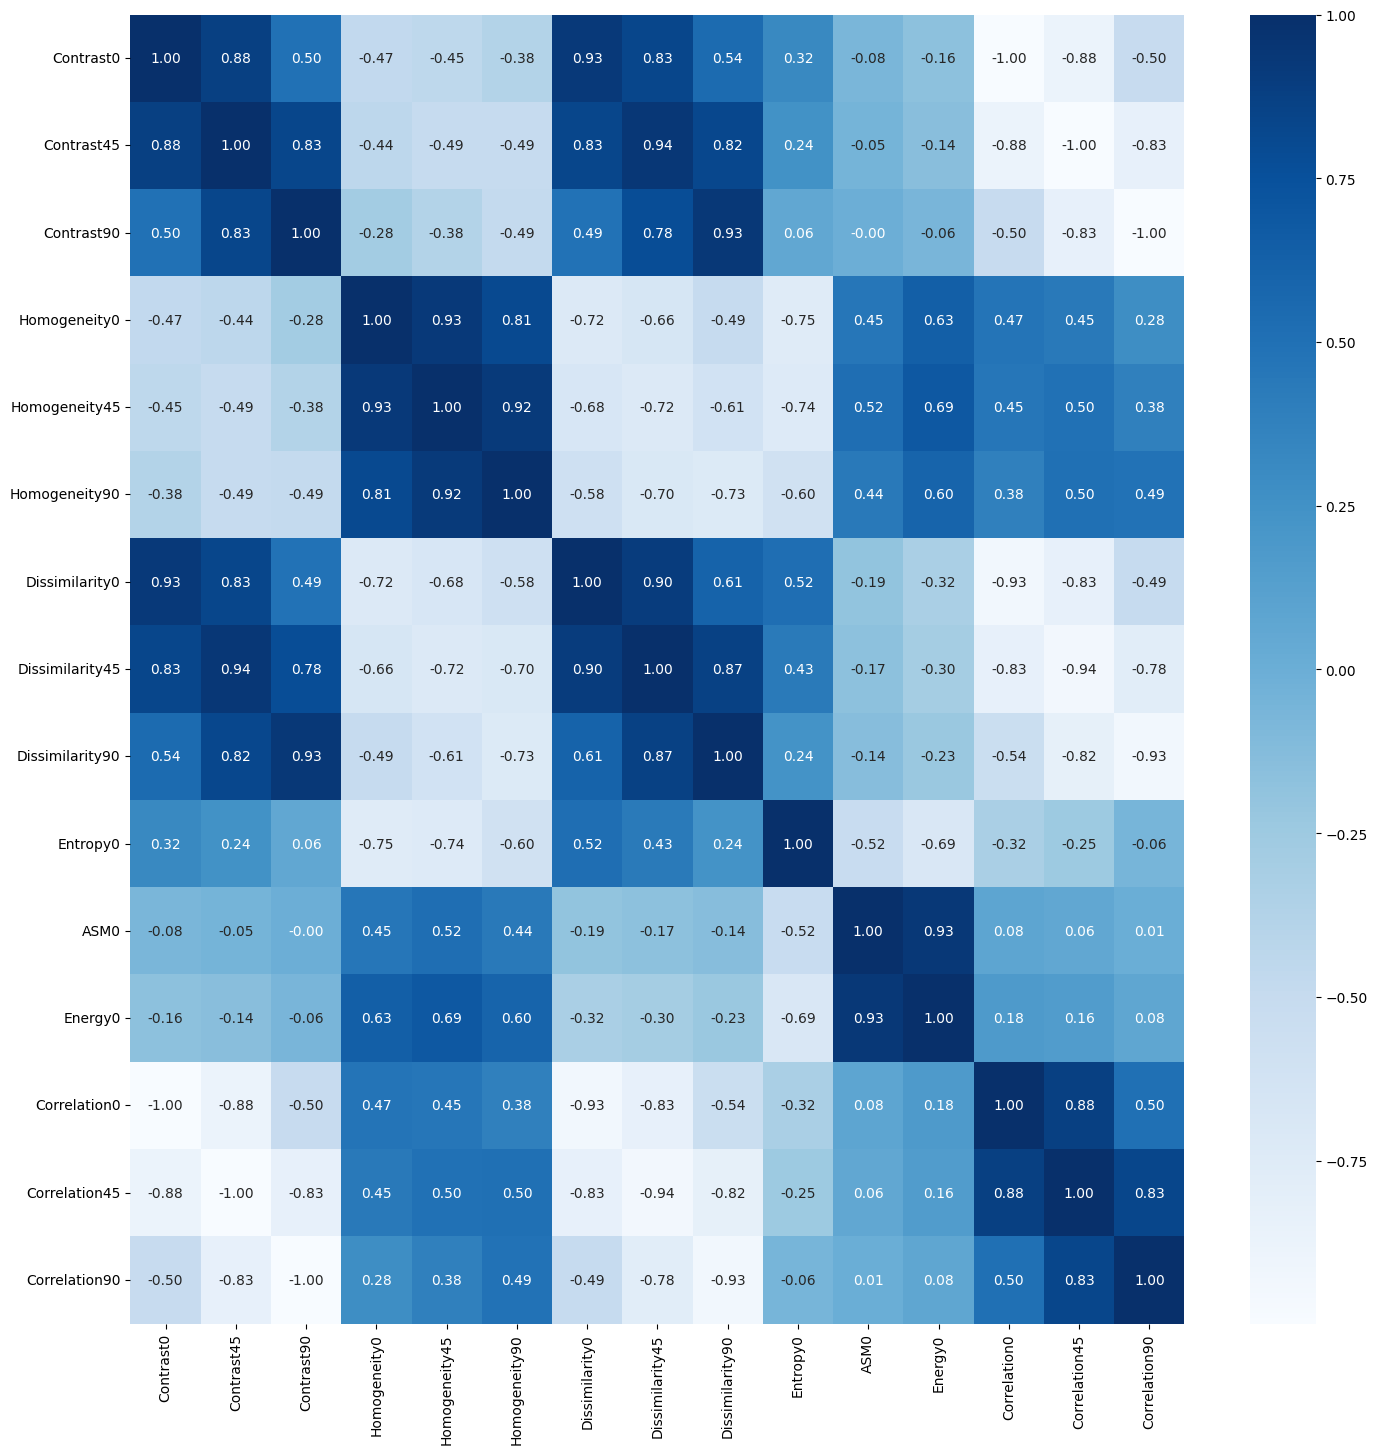

In [31]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [32]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(960, 15)
(240, 15)


In [33]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [34]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)

In [35]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

  Lumpy_Skin       1.00      1.00      1.00       478
 Normal_Skin       1.00      1.00      1.00       482

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960

[[478   0]
 [  0 482]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.92      0.92      0.92       122
 Normal_Skin       0.92      0.92      0.92       118

    accuracy                           0.92       240
   macro avg       0.92      0.92      0.92       240
weighted avg       0.92      0.92      0.92       240

[[112  10]
 [ 10 108]]
Accuracy: 0.9166666666666666


In [36]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.74      0.86      0.79       478
 Normal_Skin       0.83      0.70      0.76       482

    accuracy                           0.78       960
   macro avg       0.78      0.78      0.78       960
weighted avg       0.78      0.78      0.78       960

[[409  69]
 [145 337]]
Accuracy: 0.7770833333333333

------Testing Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.73      0.84      0.78       122
 Normal_Skin       0.81      0.67      0.73       118

    accuracy                           0.76       240
   macro avg       0.77      0.76      0.76       240
weighted avg       0.77      0.76      0.76       240

[[103  19]
 [ 39  79]]
Accuracy: 0.7583333333333333


In [37]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.94      0.96      0.95       478
 Normal_Skin       0.96      0.94      0.95       482

    accuracy                           0.95       960
   macro avg       0.95      0.95      0.95       960
weighted avg       0.95      0.95      0.95       960

[[458  20]
 [ 31 451]]
Accuracy: 0.946875

------Testing Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.83      0.81      0.82       122
 Normal_Skin       0.81      0.83      0.82       118

    accuracy                           0.82       240
   macro avg       0.82      0.82      0.82       240
weighted avg       0.82      0.82      0.82       240

[[99 23]
 [20 98]]
Accuracy: 0.8208333333333333


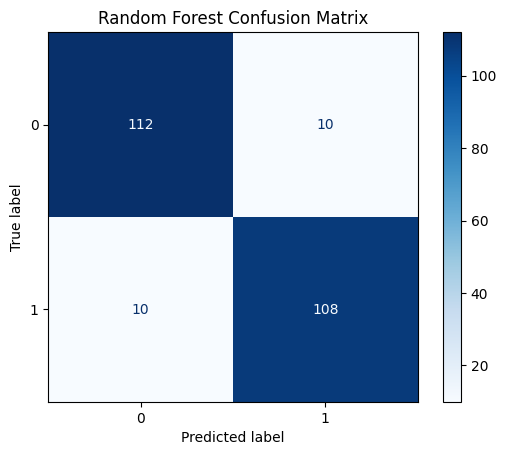

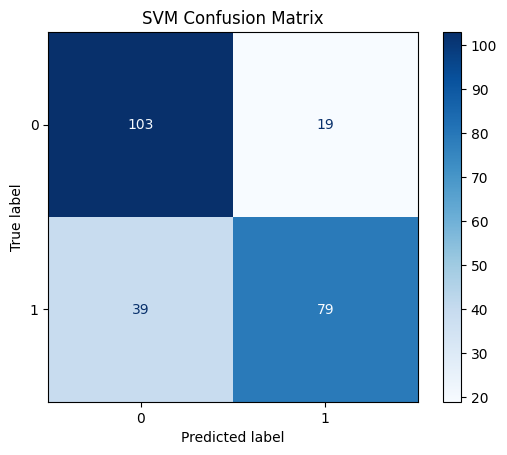

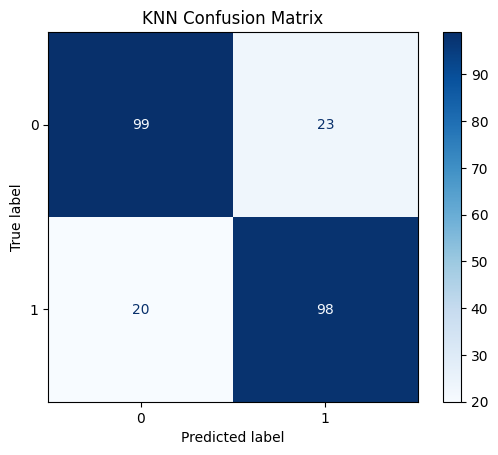

In [38]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")